<h3> Lecture fichier Jacques risque RGA par date de construction </h3>

In [ ]:
import pandas as pd
df_flat = pd.read_parquet('../csv/risques_communes_flat.parquet') # à prendre sur la branche eda-jacques-1
df_flat

,code_commune_insee,total_maisons,rga_1945_1975_faible,rga_1945_1975_moyen,rga_1945_1975_nul,rga_1945_1975_fort,rga_1976_2020_faible,rga_1976_2020_moyen,rga_1976_2020_nul,rga_1976_2020_fort,...,tri_nul_nul,tri_t01_faible,tri_t01_fort,tri_t01_moyen,tri_t02_faible,tri_t02_fort,tri_t02_moyen,tri_t03_faible,tri_t03_fort,tri_t03_moyen
0,01001,358,21,0,0,0,184,2,0,0,...,358,0,0,0,0,0,0,0,0,0
1,01002,168,1,12,0,0,2,25,3,0,...,168,0,0,0,0,0,0,0,0,0
2,01004,3254,337,165,1,0,930,869,11,0,...,3254,0,0,0,0,0,0,0,0,0
3,01005,616,82,0,0,0,328,0,2,0,...,616,0,0,0,0,0,0,0,0,0
4,01006,62,5,0,0,0,13,0,0,0,...,62,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34777,95676,253,0,18,15,25,0,16,9,37,...,253,0,0,0,0,0,0,0,0,0
34778,95678,341,0,46,1,69,0,38,0,77,...,341,0,0,0,0,0,0,0,0,0
34779,95680,1959,46,465,4,34,73,585,21,18,...,1959,0,0,0,0,0,0,0,0,0
34780,95682,69,6,0,0,0,30,0,0,0,...,69,0,0,0,0,0,0,0,0,0


<h3> Décompte du nombre de bâtiments par date de construction et par niveau de risque pour comparaison au nouveau fichier</h3>

In [9]:
df = df_flat
dfs = pd.DataFrame()

dfs.loc['pre1945', 'rga_nul'] = df.loc[:, 'rga_pre1945_nul'].sum()
dfs.loc['pre1945', 'rga_faible'] = df.loc[:, 'rga_pre1945_faible'].sum()
dfs.loc['pre1945', 'rga_moyen'] = df.loc[:, 'rga_pre1945_moyen'].sum()
dfs.loc['pre1945', 'rga_fort'] = df.loc[:, 'rga_pre1945_fort'].sum()
dfs.loc['1945-1975', 'rga_nul'] = df.loc[:, 'rga_1945_1975_nul'].sum()
dfs.loc['1945-1975', 'rga_faible'] = df.loc[:, 'rga_1945_1975_faible'].sum()
dfs.loc['1945-1975', 'rga_moyen'] = df.loc[:, 'rga_1945_1975_moyen'].sum()
dfs.loc['1945-1975', 'rga_fort'] = df.loc[:, 'rga_1945_1975_fort'].sum()
dfs.loc['1976-2020', 'rga_nul'] = df.loc[:, 'rga_1976_2020_nul'].sum()
dfs.loc['1976-2020', 'rga_faible'] = df.loc[:, 'rga_1976_2020_faible'].sum()
dfs.loc['1976-2020', 'rga_moyen'] = df.loc[:, 'rga_1976_2020_moyen'].sum()
dfs.loc['1976-2020', 'rga_fort'] = df.loc[:, 'rga_1976_2020_fort'].sum()
dfs.loc['post2020', 'rga_nul'] = df.loc[:, 'rga_post2020_nul'].sum()
dfs.loc['post2020', 'rga_faible'] = df.loc[:, 'rga_post2020_faible'].sum()
dfs.loc['post2020', 'rga_moyen'] = df.loc[:, 'rga_post2020_moyen'].sum()
dfs.loc['post2020', 'rga_fort'] = df.loc[:, 'rga_post2020_fort'].sum()
dfs.loc['unk', 'rga_nul'] = df.loc[:, 'rga_unk_nul'].sum()
dfs.loc['unk', 'rga_faible'] = df.loc[:, 'rga_unk_faible'].sum()
dfs.loc['unk', 'rga_moyen'] = df.loc[:, 'rga_unk_moyen'].sum()
dfs.loc['unk', 'rga_fort'] = df.loc[:, 'rga_unk_fort'].sum()    

df_tot = dfs.copy()
df_tot['Total'] = df_tot.sum(axis=1) 
df_tot.loc['Total'] = df_tot.sum(axis=0) 

df_tot.map(lambda x: f"{x:,.0f}".replace(",", " ") if isinstance(x, (int, float)) else x)

,rga_nul,rga_faible,rga_moyen,rga_fort,Total
pre1945,1 228 126,1 757 171,2 548 738,960 660,6 494 695
1945-1975,643 742,1 000 733,1 338 367,557 193,3 540 035
1976-2020,1 388 638,2 222 009,2 990 147,1 391 254,7 992 048
post2020,126 448,115 523,146 274,70 847,459 092
unk,5 568,7 881,11 745,4 656,29 850
Total,3 392 522,5 103 317,7 035 271,2 984 610,18 515 720


In [10]:
print("Nombre total de bâtiments : {:,.0f}".format(dfs.sum().sum()).replace(",", " "))

print("Nombre de bâtiments construits avant 1945 : {:,.0f}".format(dfs.loc['pre1945'].sum()).replace(",", " "))

print("Nombre de bâtiments construits entre 1945 et 1975 : {:,.0f}".format(dfs.loc['1945-1975'].sum()).replace(",", " "))

print("Nombre de bâtiments construits entre 1976 et 2020 : {:,.0f}".format(dfs.loc['1976-2020'].sum()).replace(",", " "))

print("Nombre de bâtiments construits après 2020 : {:,.0f}".format(dfs.loc['post2020'].sum()).replace(",", " "))

print("Nombre de bâtiments de date de construction connue : {:,.0f}".format(dfs.loc['pre1945'].sum()+ dfs.loc['1945-1975'].sum() + dfs.loc['1976-2020'].sum() + dfs.loc['post2020'].sum()).replace(",", " "))

print("Nombre de bâtiments de date de construction inconnue : {:,.0f}".format(dfs.loc['unk'].sum()).replace(",", " "))


print("")


Nombre total de bâtiments : 18 515 720
Nombre de bâtiments construits avant 1945 : 6 494 695
Nombre de bâtiments construits entre 1945 et 1975 : 3 540 035
Nombre de bâtiments construits entre 1976 et 2020 : 7 992 048
Nombre de bâtiments construits après 2020 : 459 092
Nombre de bâtiments de date de construction connue : 18 485 870
Nombre de bâtiments de date de construction inconnue : 29 850



<h3>Test affichage des données géographiques RGA</h3>

In [8]:
import pandas as pd
import geopandas as gpd
from shapely import wkb
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [9]:
# 1️⃣ Charger le GeoPackage
gdf = gpd.read_file("../dbt_pipeline/pipeline_inputs/AleaRG_2025_Fxx_L93.gpkg")


In [14]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 121399 entries, 0 to 121398
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   gid        121399 non-null  int64   
 1   insee_dep  121399 non-null  object  
 2   niveau     121399 non-null  float64 
 3   surf_m2    121399 non-null  float64 
 4   geometry   121399 non-null  geometry
dtypes: float64(2), geometry(1), int64(1), object(1)
memory usage: 4.6+ MB


In [10]:

# 2️⃣ Vérifier les premières lignes
print(gdf.head())
print(gdf.crs)

   gid insee_dep  niveau      surf_m2  \
0    1        81     3.0  2357798.774   
1    2        82     3.0    70747.495   
2    5        83     3.0   111097.419   
3    3        82     3.0   471494.469   
4    4        82     3.0   752819.323   

                                            geometry  
0  MULTIPOLYGON (((650516.669 6292366.584, 650539...  
1  MULTIPOLYGON (((601759.664 6336366.098, 601788...  
2  MULTIPOLYGON (((935880.281 6297241.517, 935887...  
3  MULTIPOLYGON (((600954.462 6338856.928, 600970...  
4  MULTIPOLYGON (((613133.401 6351636.229, 613163...  
EPSG:2154


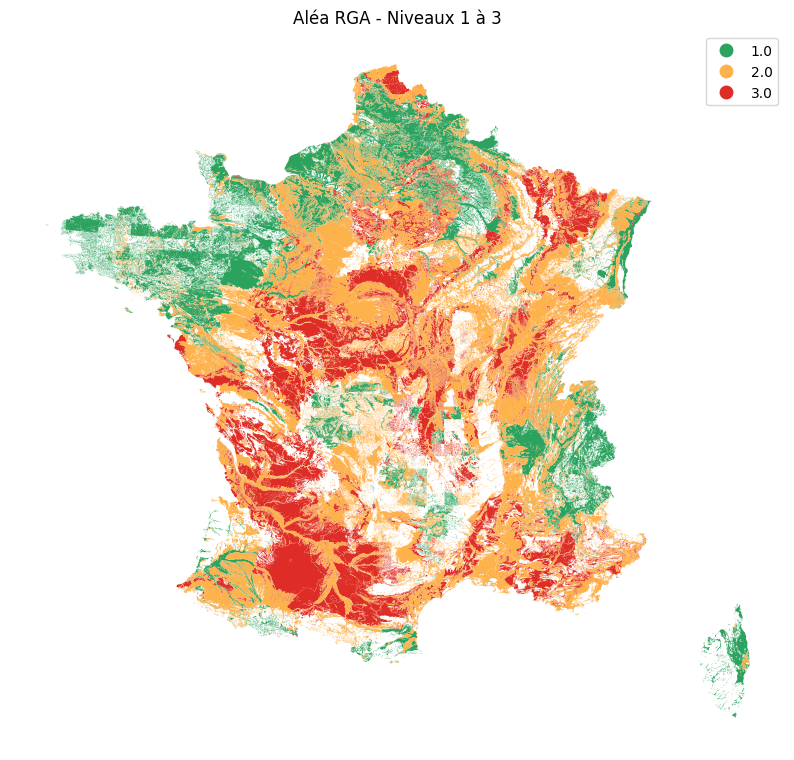

In [12]:
# Palette discrète (faible → fort)
cmap = ListedColormap(["#2ca25f", "#feb24c", "#de2d26"])

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="niveau",
    categorical=True,
    legend=True,
    cmap=cmap,
    ax=ax
)

ax.set_title("Aléa RGA - Niveaux 1 à 3")
ax.axis("off")

plt.show()